# Análisis partidas personales chess.com

El propósito del trabajo es analizar el historial de mis partidas de ajedrez en la plataforma chess.com, con el objetivo de identificar mis puntos fuertes y mis debilidades y poder tanto potenciar los primeros como centrarme en solucionar los segundos.

La plataforma chess.com expone los datos de todas las partidas jugadas a través de la API oficial: https://www.chess.com/news/view/published-data-api

Para este análisis he extraído los datos pertenecientes a mi usuario mediante el script extraccion_partidas.py y lo he guardado directamente con el nombre mis_partidas_rapid.json

La búsqueda se ha filtrado solamente a las partidas rápidas (10-30 min), que es el modo en el que suelo jugar.

In [84]:
import json

# Leemos el json con mis partidas rápidas 
with open("mis_partidas_rapid.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [85]:
import pandas as pd

# Convertimos la lista de partidas en un DataFrame expandiendo los diccionarios anidados
df_partidas = pd.json_normalize(data)

Como primer análisis me gustaría ver en que momentos de la semana obtengo mejores resultados y identificar posibles consecuencias de cansancio mental. Esto me permitiría saber a que horas debo jugar para tener un nivel competitivo, y cuando dedicarle tiempo a otros aspectos como el estudio de aperturas o conceptos técnicos. 

Para ello vamos a extraer la fecha y hora de las partidas y agruparlas en intervalos de 2 horas para visualizar un heatmap con el porcentaje de victoria por tramo.

In [86]:
# Extraemos la fecha de cada partida en horario de Madrid
df_partidas['fecha'] = pd.to_datetime(df_partidas['end_time'], unit='s') 
df_partidas['fecha_hora'] = df_partidas['fecha'].dt.tz_localize('UTC').dt.tz_convert('Europe/Madrid')

# Creamos columnas con la hora y el día de la semana
df_partidas['hora_del_dia'] = df_partidas['fecha_hora'].dt.hour  
df_partidas['dia_semana'] = df_partidas['fecha_hora'].dt.day_name()  

# Como hemos dicho, asignamos etiquetas en intervalos de dos horas 
def etiqueta_rango_2h(hora):
    inicio = (hora // 2) * 2
    # Formateamos para que quede bonito: "14:00-15:59"
    return f"{inicio:02d}:00-{inicio+1:02d}:59"

# Creamos la nueva columna de franjas horarias
df_partidas['rango_2h'] = df_partidas['hora_del_dia'].apply(etiqueta_rango_2h)

# Le decimos a Pandas el orden lógico de los días, si no, los pondrá alfabéticamente
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_partidas['dia_semana'] = pd.Categorical(df_partidas['dia_semana'], categories=dias_orden, ordered=True)

Ahora vamos a ver cuando ganan las blancas y cuando las negras, para ello mapeamos los posibles resultados de la partida (victoria: 1, empate: 0, derrota:-1):

In [87]:
df_partidas['white.result'].value_counts()

white.result
win                   1097
resigned               514
checkmated             363
abandoned               78
timeout                 38
repetition              24
stalemate               22
insufficient            16
agreed                   5
timevsinsufficient       3
Name: count, dtype: int64

In [88]:
df_partidas['black.result'].value_counts()

black.result
win                   993
resigned              536
checkmated            468
abandoned              55
timeout                38
repetition             24
stalemate              22
insufficient           16
agreed                  5
timevsinsufficient      3
Name: count, dtype: int64

In [89]:
df_partidas['resultado_blancas'] = df_partidas['white.result'].map({
    'win': 1,
    'resigned': -1,
    'checkmated': -1,
    'abandoned': -1,
    'timeout': -1,
    'repetition':0,
    'stalemate': 0,
    'insufficient': 0,
    'agreed': 0,
    'timevsinsufficient': 0
    })

df_partidas['resultado_negras'] = df_partidas['black.result'].map({
    'win': 1,
    'resigned': -1,
    'checkmated': -1,
    'abandoned': -1,
    'timeout': -1,
    'repetition':0,
    'stalemate': 0,
    'insufficient': 0,
    'agreed': 0,
    'timevsinsufficient': 0
    })

Por último, identifiquemos cuando juego con negras y cuando con blancas, y en consecuencia mi resultado en la partida.

In [90]:
import pandas as pd
import numpy as np

usuario = "pablo07as"

def resultado(fila):
    # Comprobamos si jugaba con blancas
    if fila['white.username'].lower() == usuario:
        if fila['resultado_blancas'] == 1:
            return 1
        elif fila['resultado_blancas'] == -1:
            return -1
        else:
            return 0
    # Comprobamos si jugaba con negras
    elif fila['black.username'].lower() == usuario:
        if fila['resultado_negras'] == 1:
            return 1
        elif fila['resultado_negras'] == -1:
            return -1
        else:
            return 0
    else:
        return 0

def mi_color(fila):
    if fila['white.username'].lower() == usuario:
        return 'blancas'
    elif fila['black.username'].lower() == usuario:
        return 'negras'
    else:
        return 'desconocido'

# Obtenemos la columna de color y victoria usando las funciones definidas
df_partidas['mi_color'] = df_partidas.apply(mi_color, axis=1)
df_partidas['resultado'] = df_partidas.apply(resultado, axis=1)

Para representar el rendimiento por franja horaria vamos a usar un heatmap con el porcentaje de victoria. Para ello vamos a ignorar los empates.

In [91]:
# Descartamos los empates pues no aporta información sobre el rendimiento
df_decisivo = df_partidas[df_partidas['resultado'] != 0].copy()

# Dejamos las derrotas como ceros para calcular el porcentaje con mean()
df_decisivo['victoria'] = df_decisivo['resultado'].map({1: 1, -1: 0})

# Agrupamos por día de la semana y franja horaria, calculando la media de victorias y el número de partidas
df_semanal = df_decisivo.groupby(['dia_semana', 'rango_2h'], observed=False)['victoria'].agg(['mean', 'count']).reset_index()


# Definimos un umbral mínimo de partidas por rango para considerar el porcentaje de victorias como representativo
UMBRAL_PARTIDAS = 20

df_semanal['porc_victorias'] = np.where(
    df_semanal['count'] >= UMBRAL_PARTIDAS, 
    df_semanal['mean'], 
    np.nan
)

# Creamos la tabla dinámica: cruza días (filas) con horas (columnas) y calcula la media de victorias
mapa_datos = df_semanal.pivot(
    index='dia_semana', 
    columns='rango_2h', 
    values='porc_victorias'
) * 100 

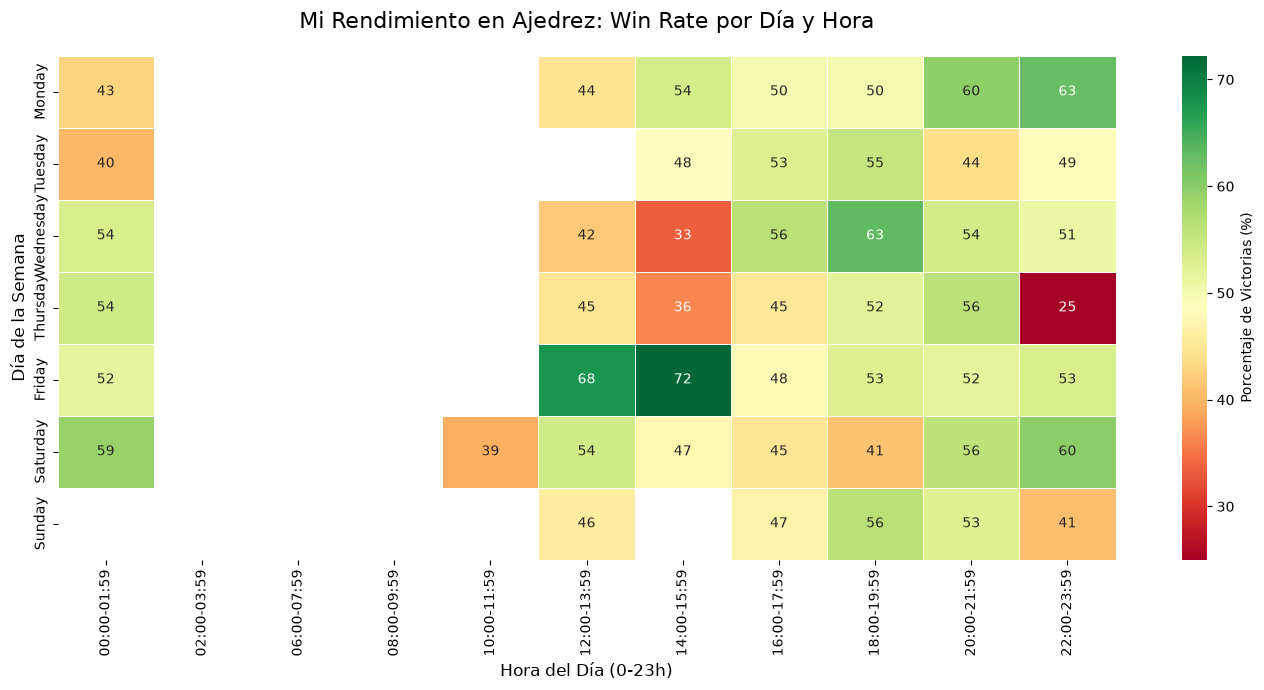

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño del lienzo (ancho, alto)
plt.figure(figsize=(14, 7))

# Pintamos el Heatmap
sns.heatmap(
    mapa_datos, 
    cmap="RdYlGn", 
    annot=True, 
    fmt=".0f", 
    linewidths=0.5,
    cbar_kws={'label': 'Porcentaje de Victorias (%)'}
)

# Añadimos títulos y etiquetas 
plt.title('Mi Rendimiento en Ajedrez: Win Rate por Día y Hora', fontsize=16, pad=20)
plt.xlabel('Hora del Día (0-23h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)

# Muestra el gráfico
plt.tight_layout()
plt.show()

Conclusiones:

### Aperturas

Es bien sabido que en el ajedrez son muy importantes las aperturas, pues determinan gran parte del desarrollo de la partida. Además, en un nivel intermedio como el mío puede suponer una gran ventaja saberse la teoría de las distintas aperturas, pues no todo el mundo las tiene estudiadas. Existen demasiadas variantes, por lo que estudiarse todas puede ser demasiado tedioso. Por lo tanto, vamos a intentar ver cuales son las más comunes en mis partidas y con cuales obtengo mejores resultados, tanto con las que abro yo la partida siendo blancas como las que utilizan mis rivales cuando juego con negras.

Para esta visualización vamos a usar dos treemaps, uno para mis aperturas con blancas y otro para las aperturas de mis adversarios. El color representará de nuevo el porcentaje de victoria, por lo que podremos identificar de un vistazo las aperturas más comunes que me suelen hacer perder en ambos casos.

En general, obtengo mejores resultados jugando con blancas, por lo que para que se pueda comparar si una apertura me hace ganar o perder más que la media jugando con ese color, calcularemos el porcentaje de victoria para cada uno de ellos, pudiendo usar ese valor como color neutral.

De nuevo volvemos a usar df_decisivo, en el cual hemos descartado los empates y las derrotas se marcan con un 0.

In [93]:
import pandas as pd
import plotly.express as px
import re

def extraer_apertura(pgn_texto):
    # Usamos una expresión regular para buscar el texto después de 'openings/'
    match = re.search(r'\[ECOUrl "https://www.chess.com/openings/([^"]+)"\]', str(pgn_texto))
    if match:
        # Reemplazamos los guiones por espacios para que el nombre se lea bien
        apertura = match.group(1).replace('-', ' ')
        return apertura
    return "Desconocida"

# Creamos la nueva columna leyendo el interior del PGN
df_decisivo['apertura'] = df_decisivo['pgn'].apply(extraer_apertura)

In [94]:
# Calculamos el porcentaje de victorias por color para luego compararlas en relación a al media
porc_victoria_blancas = df_decisivo[df_decisivo['mi_color'] == 'blancas']['victoria'].mean() * 100
porc_victoria_negras = df_decisivo[df_decisivo['mi_color'] == 'negras']['victoria'].mean() * 100

print("Tengo un {:.2f}% de victorias con blancas y un {:.2f}% con negras".format(porc_victoria_blancas, porc_victoria_negras))

Tengo un 53.57% de victorias con blancas y un 48.58% con negras


In [95]:
# Agrupamos por color y apertura, calculando el número de partidas y el porcentaje de victorias
df_analisis = df_decisivo.groupby(['mi_color', 'apertura']).agg(
    volumen_partidas=('victoria', 'count'),
    porcentaje_win=('victoria', lambda x: x.mean() * 100)
).reset_index()

# Filtramos las que tienen menos de 10 partidas y redondeamos
df_analisis = df_analisis[df_analisis['volumen_partidas'] >= 10].reset_index(drop=True)
df_analisis['porcentaje_win'] = df_analisis['porcentaje_win'].round(1)

In [96]:
# Separamos en dos dataframes, uno para mis partidas con blancas y otro para mis partidas con negras
df_blancas = df_analisis[df_analisis['mi_color'] == 'blancas']
df_negras = df_analisis[df_analisis['mi_color'] == 'negras']

In [97]:
paleta = ['#8B0000', "#C85858", '#66FF66', '#006400']


fig_blancas = px.treemap(
    df_blancas, 
    path=[px.Constant("Mis aperturas con blancas"), 'apertura'], 
    values='volumen_partidas',                              
    color='porcentaje_win',                                 
    color_continuous_scale=paleta,                        
    range_color=[porc_victoria_blancas-15, porc_victoria_blancas+15],                     
    title='Jugando con Blancas: Mis Mejores y Peores Aperturas'
)

fig_blancas.update_traces(
    hovertemplate='<b>%{label}</b><br>Partidas: %{value}<br>Win Rate: %{color}%<extra></extra>',
    textinfo="label+value" 
)
fig_blancas.update_layout(margin=dict(t=50, l=25, r=25, b=25))


fig_negras = px.treemap(
    df_negras, 
    path=[px.Constant("Mis defensas con negras"), 'apertura'], 
    values='volumen_partidas',                              
    color='porcentaje_win',                                 
    color_continuous_scale=paleta,                        
    range_color=[porc_victoria_negras-15, porc_victoria_negras+15],                     
    title='Jugando con Negras: Mis Mejores y Peores Defensas'
)

fig_negras.update_traces(
    hovertemplate='<b>%{label}</b><br>Partidas: %{value}<br>Win Rate: %{color}%<extra></extra>',
    textinfo="label+value" 
)
fig_negras.update_layout(margin=dict(t=50, l=25, r=25, b=25))

fig_blancas.show()
fig_negras.show()

Conclusiones:

Ahora vamos a analizar mi ritmo de juego,

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

def contar_movimientos(pgn_texto):
    # Buscamos todos los números seguidos de un punto 
    coincidencias = re.findall(r'(\d+)\.', str(pgn_texto))
    if coincidencias:
        # El último número de la lista es el movimiento final de la partida
        return int(coincidencias[-1])
    return 0

# Creamos la nueva columna
df_partidas['num_movimientos'] = df_partidas['pgn'].apply(contar_movimientos)

In [99]:
# Filtramos las partidas "abortadas" (menos de 3 movimientos) para que no ensucien
df_movimientos = df_partidas[df_partidas['num_movimientos'] >= 3].copy()

# Creamos una columna de texto limpio para la leyenda
df_movimientos['Resultado partida'] = df_movimientos['resultado'].map({1: 'Victoria', 0: 'Empate', -1: 'Derrota'})

In [101]:
import pandas as pd
import numpy as np
import plotly.express as px

# # 1. GENERACIÓN DE DATOS SIMULADOS (Reemplaza esto con tu DataFrame de chess.com)
# # Simulamos 300 partidas jugadas en los últimos meses
# np.random.seed(42)
# fechas = pd.date_range(start="2023-01-01", periods=300, freq="D")
# # Simulamos cantidad de movimientos (media de 35, desviación de 15)
# movimientos = np.abs(np.random.normal(loc=35, scale=15, size=300)).astype(int)
# # Resultados aleatorios
# resultados = np.random.choice(['Victoria', 'Derrota', 'Tablas'], size=300, p=[0.45, 0.45, 0.10])

# df = pd.DataFrame({'Fecha': fechas, 'Movimientos': movimientos, 'Resultado': resultados})

df_movimientos['resultado_texto'] = df_movimientos['resultado'].map({1: 'Victoria', -1: 'Derrota', 0: 'Tablas'})

fig = px.violin(
    df_movimientos,
    x="resultado_texto",      # Eje X categórico
    y="num_movimientos",      # Eje Y con la longitud de la partida
    color="resultado_texto",  # Un color para cada resultado
    color_discrete_map={
        "Victoria": "#2ecc71", # Verde
        "Derrota": "#e74c3c",  # Rojo
        "Tablas": "#95a5a6"    # Gris
    },
    box=True,                 # Muestra un pequeño diagrama de caja dentro del violín
    title="Distribución de Movimientos según el Resultado de la Partida",
    labels={
        "resultado_texto": "Resultado",
        "num_movimientos": "Número de Movimientos"
    }
)

# 3. Forzamos el orden del eje X para que sea más intuitivo
fig.update_xaxes(categoryorder='array', categoryarray=['Victoria', 'Tablas', 'Derrota'])

# Mostrar gráfico
fig.show()

In [ ]:
import pandas as pd
import re

def extraer_tiempos_rapid_10(pgn):
    # Extraemos todas las marcas de reloj directamente
    marcas_reloj = re.findall(r'\[%clk (.*?)\]', str(pgn))
    
    tiempos_blancas = []
    tiempos_negras = []
    
    # El reloj siempre empieza en 600 segundos exactos
    reloj_previo_blancas = 600
    reloj_previo_negras = 600
    
    for i, marca in enumerate(marcas_reloj):
        h, m, s = marca.split(':')
        segundos_restantes = int(h) * 3600 + int(m) * 60 + float(s)
        
        if i % 2 == 0:  # Turno de las Blancas
            tiempo_consumido = reloj_previo_blancas - segundos_restantes
            tiempos_blancas.append(max(0, round(tiempo_consumido, 1)))
            reloj_previo_blancas = segundos_restantes
        else:           # Turno de las Negras
            tiempo_consumido = reloj_previo_negras - segundos_restantes
            tiempos_negras.append(max(0, round(tiempo_consumido, 1)))
            reloj_previo_negras = segundos_restantes

    return tiempos_blancas, tiempos_negras

# Usamos lambda y pd.Series para expandir directamente el resultado en dos columnas
df_partidas[['tiempos_blancas', 'tiempos_negras']] = df_decisivo['pgn'].apply(
    lambda x: pd.Series(extraer_tiempos_rapid_10(x))
)

df_partidas['tiempos'] = df_partidas.apply(lambda row: row['tiempos_blancas'] if row['mi_color'] == 'blancas' else row['tiempos_negras'], axis=1)

In [103]:
import pandas as pd
import plotly.express as px



# Explotamos la lista: si una partida tuvo 40 movimientos, esta fila se convertirá en 40 filas
df_tiempos = df_partidas.explode('tiempos')

# Aseguramos que Plotly entienda que los tiempos son números y no texto
df_tiempos['tiempos'] = pd.to_numeric(df_tiempos['tiempos'])

# 2. CREACIÓN DEL HISTOGRAMA SUPERPUESTO
fig = px.histogram(
    df_tiempos, 
    x="tiempos", 
    color="resultado",
    barmode="overlay", # Clave para que el rojo y el verde se superpongan y podamos compararlos
    color_discrete_map={
        "Victoria": "#2ecc71", 
        "Derrota": "#e74c3c"
    },
    marginal="violin", # Añadimos el perfil de densidad en la parte superior
    nbins=120,         # Ajusta este número para hacer las barras más finas o más gruesas
    opacity=0.7,
    title="Distribución del Tiempo de Reflexión: Victorias vs Derrotas",
    labels={
        "tiempos": "Tiempo pensado por movimiento (Segundos)",
        "resultado_texto": "Resultado"
    }
)

# 3. AJUSTES VISUALES (Recortar la cola)
# Es vital limitar el eje X. Seguramente tengas alguna jugada en la que pensaste 4 minutos (240 seg),
# pero si mostramos todo, la zona de 0 a 10 segundos se verá como una aguja ilegible.
fig.update_layout(
    xaxis_range=[0, 60], # Mostramos solo los movimientos de 0 a 60 segundos
    yaxis_title="Cantidad Total de Movimientos",
    plot_bgcolor="rgba(240, 240, 240, 0.8)",
    legend_title_text="Resultado de la Partida"
)

fig.show()

In [59]:
df_tiempos

,url,pgn,time_control,end_time,rated,tcn,uuid,initial_setup,fen,time_class,...,rango_2h,resultado_blancas,resultado_negras,mi_color,resultado,num_movimientos,resultado_texto,tiempos_blancas,tiempos_negras,tiempos


In [104]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

# --- 1. ORDENAR CRONOLÓGICAMENTE ---
# Es VITAL que las partidas estén ordenadas por fecha/hora exacta de juego
# Asegúrate de usar el nombre de tu columna de fecha. Supondré que se llama 'end_time'
df_rachas = df_decisivo.sort_values('end_time').copy()
df_rachas = df_rachas.reset_index(drop=True)

# --- 2. EL ALGORITMO DE RACHAS (Magia de Pandas) ---
# Creamos 'bloques' cada vez que el resultado cambia respecto a la partida anterior
df_rachas['cambio_resultado'] = (df_rachas['resultado'] != df_rachas['resultado'].shift(1)).cumsum()

# Contamos cuántas partidas llevamos dentro del mismo bloque (racha actual)
df_rachas['racha_actual'] = df_rachas.groupby('cambio_resultado').cumcount() + 1

# Damos valor positivo a las victorias y negativo a las derrotas (los empates se quedan en 0)
def calcular_valor_grafico(fila):
    if fila['resultado'] == 1:   # Victoria
        return fila['racha_actual']
    elif fila['resultado'] == -1: # Derrota
        return -fila['racha_actual']
    else:                        # Empate
        return 0

df_rachas['momentum'] = df_rachas.apply(calcular_valor_grafico, axis=1)

# --- 3. DIBUJAR EL GRÁFICO INTERACTIVO ---
# Añadimos un número de partida secuencial para el eje X
df_rachas['numero_partida'] = df_rachas.index + 1

# Creamos una columna de color para que Plotly lo pinte fácil
df_rachas['color'] = df_rachas['resultado'].map({1: '#2ca02c', 0: '#7f7f7f', -1: '#d62728'})
df_rachas['etiqueta_resultado'] = df_rachas['resultado'].map({1: 'Victoria', 0: 'Empate', -1: 'Derrota'})

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_rachas['numero_partida'],
    y=df_rachas['momentum'],
    marker_color=df_rachas['color'],
    text=df_rachas['etiqueta_resultado'],
    opacity=0.9,           
    marker_line_width=0,
    hovertemplate="Partida nº: %{x}<br>Estado: %{text}<br>Racha acumulada: %{y}<extra></extra>"
))

fig.update_layout(
    title='El Electrocardiograma Psicológico: Rachas de Victorias vs. Tilt',
    xaxis_title='Secuencia de Partidas (Cronológico)',
    yaxis_title='Longitud de la Racha',
    template='plotly_white',
    hovermode='x unified',
    margin=dict(t=60, l=40, r=40, b=40)
)

# Añadimos una línea horizontal en el 0 para marcar el punto neutro
fig.add_hline(y=0, line_width=1, line_color="black")

fig.show()

In [105]:
import plotly.express as px
import pandas as pd

MI_USUARIO = "pablo07as"

def clasificar_terminacion(fila):
    if str(fila.get('white.username', '')).lower() == MI_USUARIO:
        mi_resultado = fila['white.result']
        rival_resultado = fila['black.result']
    else:
        mi_resultado = fila['black.result']
        rival_resultado = fila['white.result']
    
    if mi_resultado == 'win':
        resultado = 'Victoria'
        metodo = rival_resultado 
    elif rival_resultado == 'win':
        resultado = 'Derrota'
        metodo = mi_resultado 
    else:
        resultado = 'Empate'
        metodo = mi_resultado 
        
    traducciones = {
        'resigned': 'Abandono',
        'checkmated': 'Jaque Mate',
        'timeout': 'Tiempo Agotado',
        'abandoned': 'Desconexión',
        'repetition': 'Repetición',
        'stalemate': 'Rey Ahogado',
        'insufficient': 'Material Insuficiente',
        'agreed': 'Mutuo Acuerdo',
        'timevsinsufficient': 'Tiempo vs Mat. Insuf.'
    }
    
    metodo_limpio = traducciones.get(metodo, str(metodo).capitalize())
    return pd.Series([resultado, metodo_limpio])

# 1. Clasificamos los resultados (asegúrate de usar tu DataFrame original, aquí lo llamo 'df')
df[['resultado_final', 'metodo_terminacion']] = df.apply(clasificar_terminacion, axis=1)

# --- 2. EL FILTRO CLAVE ---
# Nos quedamos solo con Victorias o Derrotas Y quitamos las Desconexiones
df_filtrado_plot = df[
    (df['resultado_final'].isin(['Victoria', 'Derrota'])) & 
    (df['metodo_terminacion'] != 'Desconexión')
].copy()

# 3. Agrupamos los datos ya limpios
df_metodos = df_filtrado_plot.groupby(['resultado_final', 'metodo_terminacion']).size().reset_index(name='cantidad')

# 4. Actualizamos el orden visual
orden_categorias = {"resultado_final": ["Victoria", "Derrota"]}

# 5. Dibujamos el Gráfico de Barras Frontal
fig = px.bar(
    df_metodos, 
    x='resultado_final', 
    y='cantidad', 
    color='metodo_terminacion',
    barmode='group',     
    text_auto=True,      
    category_orders=orden_categorias,
    color_discrete_sequence=['#1f77b4', '#ff7f0e', '#2ca02c'], # Colores sólidos 
    title='Autopsia del Tablero: Victorias vs. Derrotas (Excluyendo Desconexiones)'
)

fig.update_layout(
    xaxis_title='Resultado',
    yaxis_title='Volumen de Partidas',
    legend_title_text='Motivo:',
    template='plotly_white',
    margin=dict(t=60, l=40, r=40, b=40),
    font=dict(size=13)
)

fig.show()